# 4.2: Notebook-Basic pipelines

In this notebook, we will learn how to build pipelines with multiple preprocessing steps and how to access and inspect the components of a pipeline.

## Learning outcomes:
- Build pipelines with multiple preprocessing steps.
- Access individual steps in a pipeline.
- Inspect fitted parameters from pipeline components.
- Apply pipelines to real data.



In [1]:
# Import necessary libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np

Let's build a classification pipeline using the Iris dataset. This pipeline will:
1. Scale the features (StandardScaler).
2. Reduce dimensions for visualization (PCA to 2 components).
3. Classify the flowers (LogisticRegression).

This demonstrates how preprocessing steps work together before the model.

In [2]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print(f"Dataset: {len(X)} samples, {X.shape[1]} features")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


Dataset: 150 samples, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Training set: 105 samples
Test set: 45 samples


In [3]:
# Build a three-step pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),         # Step 1: Scale to mean=0, std=1
    ('pca', PCA(n_components=2)),         # Step 2: Reduce to 2 dimensions (chosen for visualisation — in practice, you would select this based on explained variance)
    ('classifier', LogisticRegression())  # Step 3: Classify
])

print("Pipeline created with 3 steps:")
print(pipeline)


Pipeline created with 3 steps:
Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('classifier', LogisticRegression())])


In [4]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# Evaluate
accuracy = pipeline.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.3f}")

# Make predictions
predictions = pipeline.predict(X_test)
print(f"\nFirst 10 predictions: {predictions[:10]}")
print(f"First 10 actual:      {y_test[:10]}")


Test accuracy: 0.911

First 10 predictions: [1 0 2 1 2 0 1 2 2 1]
First 10 actual:      [1 0 2 1 1 0 1 2 1 1]


In [5]:
# Inspect what each step learned

# Step 1: Scaler
scaler = pipeline.named_steps['scaler']
print("Step 1 - StandardScaler:")
print(f"  Feature means (before scaling): {scaler.mean_}")
print(f"  Feature stds (before scaling): {scaler.scale_}")

# Step 2: PCA
pca = pipeline.named_steps['pca']
print("\nStep 2 - PCA:")
print(f"  Reduced from {X.shape[1]} features to {pca.n_components_} components")
print(f"  Variance explained by each component: {pca.explained_variance_ratio_}")
print(f"  Total variance retained: {pca.explained_variance_ratio_.sum():.1%}")

# Step 3: Classifier
classifier = pipeline.named_steps['classifier']
print("\nStep 3 - LogisticRegression:")
print(f"  Classes: {classifier.classes_}")
print(f"  Number of iterations: {classifier.n_iter_}")


Step 1 - StandardScaler:
  Feature means (before scaling): [5.84285714 3.00952381 3.87047619 1.23904762]
  Feature stds (before scaling): [0.82932642 0.41691013 1.71313824 0.73917525]

Step 2 - PCA:
  Reduced from 4 features to 2 components
  Variance explained by each component: [0.7070102  0.24507687]
  Total variance retained: 95.2%

Step 3 - LogisticRegression:
  Classes: [0 1 2]
  Number of iterations: [17]


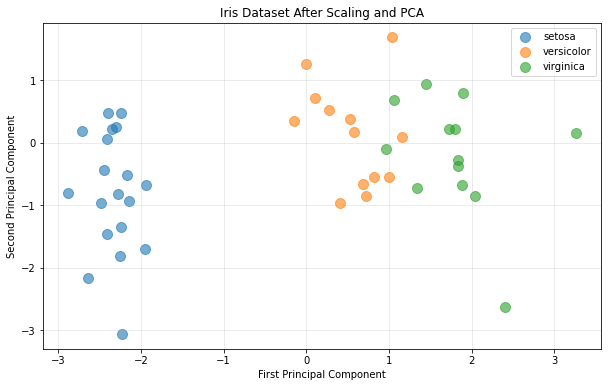

This plot shows the test data after the pipeline's preprocessing.
The 4 original features have been scaled and reduced to 2 dimensions.


In [6]:
# Visualize the pipeline's transformation
import matplotlib.pyplot as plt

# Get the data after scaling and PCA (but before classification)
X_test_transformed = pipeline[:-1].transform(X_test)

# Plot the 2D representation
plt.figure(figsize=(10, 6))

# Plot each class with a different colour
for i, class_name in enumerate(iris.target_names):
    mask = y_test == i
    plt.scatter(
        X_test_transformed[mask, 0],
        X_test_transformed[mask, 1],
        label=class_name,
        alpha=0.6,
        s=100
    )

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Iris Dataset After Scaling and PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("This plot shows the test data after the pipeline's preprocessing.")
print("The 4 original features have been scaled and reduced to 2 dimensions.")


## Saving and loading pipelines

You now have a trained pipeline that scales, reduces and classifies the Iris data correctly. But what happens when you close this notebook? All the fitted parameters — the scaler's means, the PCA components, the model weights — are lost. Once you have built and trained a pipeline, you will want to save it so you can:
- Use it later without retraining.
- Share it with teammates.
- Deploy it to production.
- Keep a record of your experiments.

Let us learn how to save and load pipelines using `joblib`.

In [7]:
import joblib
import os
from datetime import datetime

# Save the pipeline we just trained
filename = 'iris_classifier_pipeline.pkl'
joblib.dump(pipeline, filename)

print(f"Pipeline saved to: {filename}")
print(f"File size: {os.path.getsize(filename) / 1024:.2f} KB")

Pipeline saved to: iris_classifier_pipeline.pkl
File size: 1.98 KB


In [8]:
# Check that the file was created
if os.path.exists(filename):
    print(f"✓ File '{filename}' exists")
    print(f"  Created: {datetime.fromtimestamp(os.path.getctime(filename))}")
else:
    print(f"✗ File '{filename}' not found")

✓ File 'iris_classifier_pipeline.pkl' exists
  Created: 2026-07-10 11:42:02.297077


## Loading and using the saved pipeline

Let's simulate loading the pipeline in a new session (as if we're using it days or weeks later, or on a different machine).

In [9]:
loaded_pipeline = joblib.load(filename)

print(f"\nPipeline structure:")
print(loaded_pipeline)


Pipeline structure:
Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('classifier', LogisticRegression())])


In [10]:
# Verify the loaded pipeline works exactly the same
# Make predictions with the loaded pipeline
loaded_predictions = loaded_pipeline.predict(X_test)
loaded_accuracy = loaded_pipeline.score(X_test, y_test)

print("Loaded pipeline predictions:")
print(f"  Accuracy: {loaded_accuracy:.3f}")
print(f"  First 10 predictions: {loaded_predictions[:10]}")

# Compare with original pipeline
print("\nOriginal pipeline predictions:")
print(f"  Accuracy: {accuracy:.3f}")
print(f"  First 10 predictions: {predictions[:10]}")

# Verify they're identical
if (loaded_predictions == predictions).all():
    print("\n✓ Loaded pipeline produces identical results!")
else:
    print("\n✗ Results differ (something went wrong)")

Loaded pipeline predictions:
  Accuracy: 0.911
  First 10 predictions: [1 0 2 1 2 0 1 2 2 1]

Original pipeline predictions:
  Accuracy: 0.911
  First 10 predictions: [1 0 2 1 2 0 1 2 2 1]

✓ Loaded pipeline produces identical results!


## What gets saved?

When you save a pipeline, **everything** is preserved:
- All fitted parameters (scaler means/stds, PCA components, model weights).
- The pipeline structure (which steps, in what order).
- All hyperparameters (number of PCA components, model settings).

This means you can use the loaded pipeline immediately on new data without any retraining!

In [11]:
# Use the loaded pipeline on completely new data
# Let's create a new sample (imagine this is a new flower measurement)
new_flower = [[5.1, 3.5, 1.4, 0.2]]  # Measurements: sepal length, sepal width, petal length, petal width

# Predict with loaded pipeline
prediction = loaded_pipeline.predict(new_flower)
probabilities = loaded_pipeline.predict_proba(new_flower)

print("New flower prediction:")
print(f"  Predicted class: {iris.target_names[prediction[0]]}")
print(f"  Confidence: {probabilities[0][prediction[0]]:.2%}")
print(f"\nProbabilities for each class:")
for i, class_name in enumerate(iris.target_names):
    print(f"  {class_name}: {probabilities[0][i]:.2%}")

New flower prediction:
  Predicted class: setosa
  Confidence: 98.09%

Probabilities for each class:
  setosa: 98.09%
  versicolor: 1.91%
  virginica: 0.00%


## Best practices for saving pipelines

**1. Use descriptive filenames with timestamps:**
```python
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'iris_pipeline_{timestamp}.pkl'
```

**2. Save metadata separately:**
Metadata is information about your pipeline rather than the pipeline itself — things like when it was trained, what data it used and what performance it achieved. Saving this alongside your pipeline means you can always trace where a model came from, which is important when you have multiple versions.


```python
metadata = {
    'accuracy': accuracy,
    'n_features': X.shape[1],
    'n_samples': len(X),
    'date': datetime.now().isoformat()
}
joblib.dump(metadata, 'iris_pipeline_metadata.pkl')
```

**3. Always verify after saving:**
- Load the pipeline immediately after saving.
- Make a test prediction to ensure it works.
- Compare results with the original pipeline.


In [12]:
# Example: Save with timestamp and metadata
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
pipeline_filename = f'iris_pipeline_{timestamp}.pkl'
metadata_filename = f'iris_pipeline_{timestamp}_metadata.pkl'

# Save pipeline
joblib.dump(pipeline, pipeline_filename)

# Save metadata
metadata = {
    'model': 'Iris Classifier Pipeline',
    'accuracy': accuracy,
    'n_features_original': X.shape[1],
    'n_features_transformed': 2,  # After PCA
    'n_samples_train': len(X_train),
    'n_samples_test': len(X_test),
    'timestamp': timestamp,
    'pipeline_steps': list(pipeline.named_steps.keys())
}
joblib.dump(metadata, metadata_filename)

print(f"Pipeline saved to: {pipeline_filename}")
print(f"Metadata saved to: {metadata_filename}")
print("\nMetadata contents:")
for key, value in metadata.items():
    print(f"  {key}: {value}")


Pipeline saved to: iris_pipeline_20260710_114202.pkl
Metadata saved to: iris_pipeline_20260710_114202_metadata.pkl

Metadata contents:
  model: Iris Classifier Pipeline
  accuracy: 0.9111111111111111
  n_features_original: 4
  n_features_transformed: 2
  n_samples_train: 105
  n_samples_test: 45
  timestamp: 20260710_114202
  pipeline_steps: ['scaler', 'pca', 'classifier']


## Key takeaways

**Building pipelines:**
- Use a list of `(name, transformer)` tuples.
- Each step transforms data and passes it to the next step.
- The last step is almost always a predictor (such as a classifier or regressor) in a supervised learning pipeline. It can also be a transformer if you only need to preprocess data without making predictions, but calling predict() on such a pipeline will fail.

**Accessing steps:**
- By name: `pipeline.named_steps['step_name']`.
- By index: `pipeline[0]`, `pipeline[-1]`.
- Get intermediate results: `pipeline[:-1].transform(X)`.

**Saving and loading:**
- Save with: `joblib.dump(pipeline, 'filename.pkl')`.
- Load with: `loaded_pipeline = joblib.load('filename.pkl')`.
- Everything is preserved: fitted parameters, structure and hyperparameters.

